# Nested Clustered Optimization: a cure for Markowitz's curse

A Python translation of the Julia lecture `L16_notes.jl` (OJEDS Fall 2023).

The lesson has two halves. First we reproduce **plain Markowitz portfolio optimization** (constrained least squares, VMLS Ch. 17) and watch it fall apart out of sample — *Markowitz's curse*. Then we fix it with **Nested Clustered Optimization (NCO)** following López de Prado, *Machine Learning for Asset Managers* (MLDP), §7.6: cluster the assets by correlation distance, optimize *within* each cluster, then optimize a *portfolio of those cluster portfolios*.

Data: the exact `portfolio_data()` series from the VMLS package, exported to `vmls_portfolio_returns.csv` — 2500 daily returns on 20 assets (19 stocks + 1 risk-free), split chronologically into a 2000-day training set $R$ and a non-overlapping 500-day test set $R^{\text{test}}$.

*With thanks to Joe Schneider for helping develop the original NCO example.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
rng = np.random.default_rng(778)  # mirrors Random.seed!(778) in the Julia source

## Data

`vmls_portfolio_returns.csv` holds all 2500 daily returns chronologically. The split matches the Julia `portfolio_data()` exactly:

- $R$ = rows 1–2000 (training)
- $R^{\text{test}}$ = rows 2001–2500 (test)

Each is a $T \times n$ matrix: $T$ periods (days), $n = 20$ assets.

In [2]:
returns = pd.read_csv("vmls_portfolio_returns.csv").to_numpy()
R      = returns[:2000, :]    # training: days 1-2000
R_test = returns[2000:, :]    # test:     days 2001-2500

T, n = R.shape
T_test, _ = R_test.shape
print(f"R      : {R.shape}  (T periods x n assets)")
print(f"R_test : {R_test.shape}")
print(f"assets : 19 stocks + 1 risk-free = {n}")

R      : (2000, 20)  (T periods x n assets)
R_test : (500, 20)
assets : 19 stocks + 1 risk-free = 20


## Part 1 — Plain Markowitz, and the curse

### Portfolio value with reinvestment

Start with \$10,000 and compound $(1 + r_t)$ each period. This wealth path is the yardstick for every comparison below.

$$V_t = 10000 \prod_{s \le t} (1 + r_s)$$

In [3]:
def cum_value(r):
    return 10_000 * np.cumprod(1 + np.asarray(r))

### The optimizer: constrained least squares (VMLS §17.1)

Choose weights $w$ to minimize portfolio return variance subject to the budget constraint $\mathbf{1}^\top w = 1$ and a target expected return $\mu^\top w = \rho$. With $\mu = \tfrac1T \sum_t R_t$ (the per-asset mean), the KKT optimality conditions form the linear system

$$
\begin{bmatrix} 2R^\top R & \mathbf{1} & \mu \\ \mathbf{1}^\top & 0 & 0 \\ \mu^\top & 0 & 0 \end{bmatrix}
\begin{bmatrix} w \\ z_1 \\ z_2 \end{bmatrix}
=
\begin{bmatrix} 2\rho T \mu \\ 1 \\ \rho \end{bmatrix},
$$

where $z_1, z_2$ are Lagrange multipliers. A single asset (a cluster of size 1, later) trivially gets weight 1.

In [4]:
def port_opt(Rm, rho):
    T, n = Rm.shape
    if n == 1:
        return np.array([1.0])
    mu = Rm.sum(axis=0) / T                      # (n,) per-asset mean return
    KKT = np.block([
        [2 * Rm.T @ Rm,            np.ones((n, 1)), mu.reshape(n, 1)],
        [np.ones((1, n)),          np.zeros((1, 1)), np.zeros((1, 1))],
        [mu.reshape(1, n),         np.zeros((1, 1)), np.zeros((1, 1))],
    ])
    rhs = np.concatenate([2 * rho * T * mu, [1.0], [rho]])
    w = np.linalg.solve(KKT, rhs)[:n]
    return w

### Optimize for a 10% annual target, look in sample

$\rho = 0.10 / 250$ — a 10% annual return expressed per trading day (~250 days/year). In sample the optimized portfolio looks excellent.

In-sample average annual return: 10.0000%


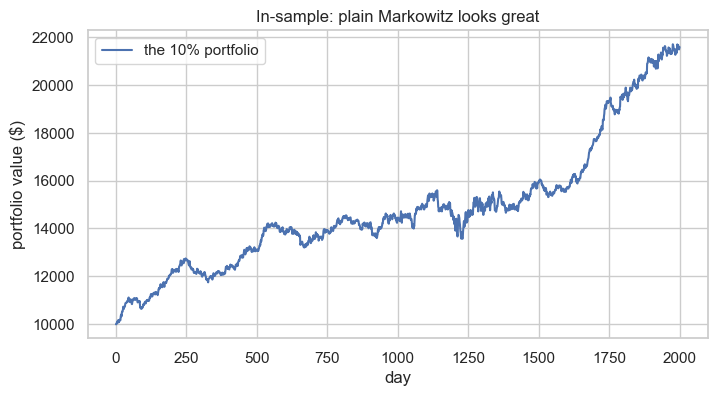

In [5]:
rho = 0.10 / 250  # 10% annual target, per trading day

w = port_opt(R, rho)
r = R @ w
print(f"In-sample average annual return: {250 * r.mean():.4%}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, T + 1), cum_value(r), label="the 10% portfolio")
plt.title("In-sample: plain Markowitz looks great")
plt.xlabel("day"); plt.ylabel("portfolio value ($)")
plt.legend(loc="upper left"); plt.show()

### Out of sample: Markowitz's curse

Reuse the *same training weights* on the non-overlapping test set. Against even a naive "steady 10%" benchmark, the optimized portfolio underperforms badly. The optimizer overfit a noisy, nearly singular in-sample covariance matrix, so the weights do not generalize.

Out-of-sample average annual return: 7.6065%


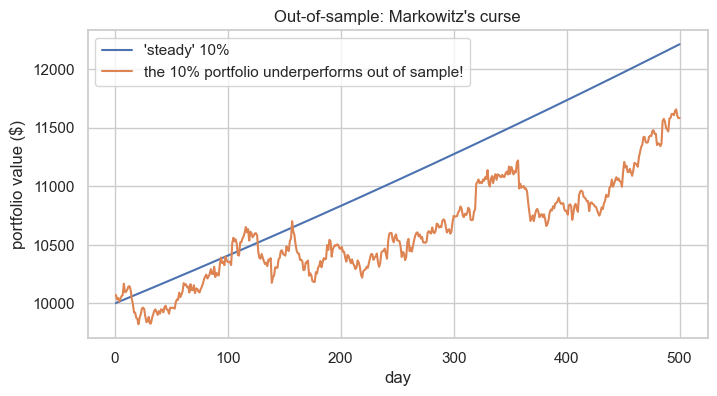

In [6]:
r_test = R_test @ w
print(f"Out-of-sample average annual return: {250 * r_test.mean():.4%}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, T_test + 1), cum_value(rho * np.ones(T_test)), label="'steady' 10%")
plt.plot(range(1, T_test + 1), cum_value(r_test),
         label="the 10% portfolio underperforms out of sample!")
plt.title("Out-of-sample: Markowitz's curse")
plt.xlabel("day"); plt.ylabel("portfolio value ($)")
plt.legend(loc="upper left"); plt.show()

## Part 2 — The fix: Nested Clustered Optimization

Don't invert one big unstable covariance matrix. Group similar assets, optimize *within* each small (well-conditioned) group, then optimize *across* the group portfolios. Estimation errors stay local instead of propagating through the whole matrix.

### Step 1 — Cluster assets by correlation distance

MLDP (p. 54) turns a correlation matrix into a distance matrix:

$$D_{ij} = \sqrt{\tfrac12\,(1 - \rho_{ij})}$$

Perfectly correlated assets have distance 0; perfectly anticorrelated, distance 1. Column $i$ of $D$ is asset $i$'s *correlation-distance vector* — its dissimilarity profile against every other asset, which is what we cluster on. We use $k$-means with $k = 5$ (the textbook's Ch. 4 method).

In [7]:
def codist(S):
    # correlation-distance matrix (MLDP p. 54); np.corrcoef wants variables in rows
    C = np.corrcoef(S, rowvar=False)
    return np.sqrt(0.5 * (1.0 - C))

D = codist(R)
x = [D[:, i] for i in range(n)]   # one correlation-distance vector per asset
k = 5

### $k$-means from scratch (textbook Ch. 4)

Standard Lloyd's algorithm, kept explicit rather than calling a library, exactly as in the Julia source: random initial assignment, then alternate (i) recompute each cluster representative as the mean of its members and (ii) reassign each point to its nearest representative, stopping when the clustering objective $J$ stops improving.

In [8]:
def kmeans_(x, k, maxiters=100, tol=1e-5, rng=rng):
    N = len(x)
    d = len(x[0])
    distances = np.zeros(N)
    assignment = rng.integers(1, k + 1, size=N)   # initial random assignment in 1..k
    reps = [np.zeros(d) for _ in range(k)]
    Jprev = np.inf
    for it in range(1, maxiters + 1):
        for j in range(1, k + 1):                  # representative = mean of members
            group = np.where(assignment == j)[0]
            if len(group) > 0:
                reps[j - 1] = np.mean([x[i] for i in group], axis=0)
        for i in range(N):                         # reassign to nearest representative
            dd = [np.linalg.norm(x[i] - reps[j]) for j in range(k)]
            distances[i] = np.min(dd)
            assignment[i] = int(np.argmin(dd)) + 1
        J = np.linalg.norm(distances) ** 2 / N
        print(f"Iteration {it}: Jclust = {J}.")
        if it > 1 and abs(J - Jprev) < tol * J:
            return assignment, reps
        Jprev = J
    return assignment, reps

assignment, reps = kmeans_(x, k)
labels = assignment            # cluster label (1..k) for each asset
print("cluster sizes:", [int((labels == i).sum()) for i in range(1, k + 1)])

Iteration 1: Jclust = 0.24647934512524552.
Iteration 2: Jclust = 0.23849401559982022.
Iteration 3: Jclust = 0.23849401559982022.
cluster sizes: [5, 3, 4, 5, 3]


### Step 2 — Optimize within each cluster

Split the training matrix by cluster label and run `port_opt` independently inside each group, all targeting the same $\rho$. Each small covariance matrix is far better conditioned than the full $20 \times 20$ one. (This is why the single-asset base case in `port_opt` matters: a cluster can have one member.) Stack the cluster portfolios' in-sample return series into a $T \times k$ matrix — effectively $k$ synthetic "assets," one per cluster.

In [9]:
P  = [R[:, labels == i] for i in range(1, k + 1)]          # training, by cluster
w_p = [port_opt(P[i], rho) for i in range(k)]              # within-cluster weights
r_p = [P[i] @ w_p[i] for i in range(k)]                    # in-sample cluster returns
Pr  = np.column_stack(r_p)                                 # T x k
print("within-cluster weight vector lengths:", [len(wi) for wi in w_p])

within-cluster weight vector lengths: [5, 3, 4, 5, 3]


### Step 3 — Portfolio of portfolios

Run `port_opt` *again*, now on the $k$ cluster-return series. This nested outer optimization allocates capital *across* clusters.

In [10]:
w_pp = port_opt(Pr, rho)        # across-cluster weights
r_pp = Pr @ w_pp                # combined in-sample return series
print(f"NCO in-sample average annual return: {250 * r_pp.mean():.4%}")

NCO in-sample average annual return: 10.0000%


### Out-of-sample evaluation

The honest test: reuse the weights learned on training data. Split the *test* set into the same clusters, apply the *training* within-cluster weights $w_p$, then the *training* across-cluster weights $w_{pp}$.

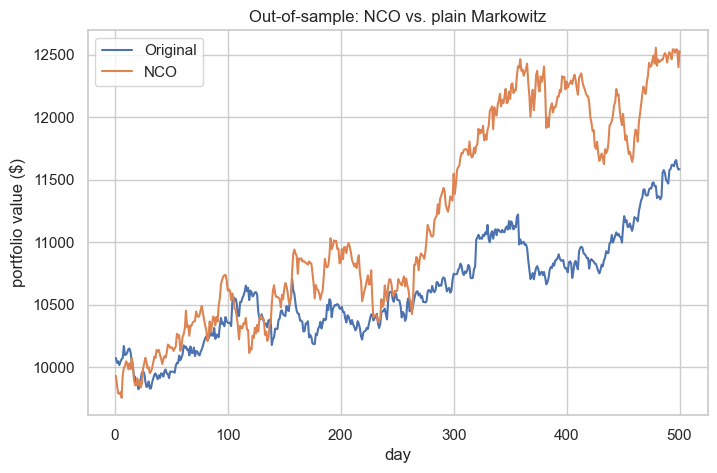

,final wealth ($),OOS gain
Original (plain Markowitz),"11,583.81",15.84%
NCO,"12,529.61",25.30%


In [11]:
P_test  = [R_test[:, labels == i] for i in range(1, k + 1)]
r_p_test = [P_test[i] @ w_p[i] for i in range(k)]
Pr_test  = np.column_stack(r_p_test)
r_pp_test = Pr_test @ w_pp

plt.figure(figsize=(8, 5))
plt.plot(range(1, T_test + 1), cum_value(r_test),    label="Original")
plt.plot(range(1, T_test + 1), cum_value(r_pp_test), label="NCO")
plt.title("Out-of-sample: NCO vs. plain Markowitz")
plt.xlabel("day"); plt.ylabel("portfolio value ($)")
plt.legend(loc="upper left"); plt.show()

summary = pd.DataFrame({
    "final wealth ($)": [cum_value(r_test)[-1], cum_value(r_pp_test)[-1]],
    "OOS gain":         [cum_value(r_test)[-1] / 10_000 - 1,
                         cum_value(r_pp_test)[-1] / 10_000 - 1],
}, index=["Original (plain Markowitz)", "NCO"])
summary.style.format({"final wealth ($)": "{:,.2f}", "OOS gain": "{:.2%}"})

### Takeaway

Two nested *small, well-conditioned* optimizations replace one *large, ill-conditioned* one. Plain Markowitz overfits the noisy in-sample covariance and barely beats a flat line out of sample; NCO degrades far less because clustering shrinks the noisy off-diagonal terms the naive optimizer chased.

**Next refinement (discussed, not coded here):** cross-validation with *purging and embargo*. When observations overlap in time, a naive train/test split leaks information; MLDP's purged & embargoed CV removes train observations whose labels overlap the test window. That is the natural sequel to this notebook.